This notebook loads paired predator–prey expert trajectory windows, pretrains prey and predator transition encoders with VicReg-style augmentation, and then pretrains predator and prey policies via behavior cloning with early stopping. This pretraining is done for all data as well as attack only data.

### Pretrain Policy & Encoder

In [ ]:
# import libraries + set working directory
import os, sys
import numpy as np
from pathlib import Path

drive = "/path/to/project"
drive = Path(drive)

os.chdir(drive)
sys.path.insert(0, drive)

print("Working directory:", os.getcwd())

Working directory: /path/to/project


In [ ]:
import torch
from pathlib import Path
from datetime import datetime

# project specific helper modules
from utils.sim_utils import *
from utils.train_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *

from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator

In [ ]:
window_len = 10
window_path = drive / f'Data/1. Data Processing/Processed/video/expert_tensors/windows/{window_len} windows'

print(sorted(os.listdir(window_path)))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

['pred_tensor_w10_n24.pt', 'pred_tensors_hl_w10_n3747.pkl', 'prey_tensor_w10_n24.pt', 'prey_tensors_hl_w10_n3747.pkl']


In [ ]:
def load_expert_pairs(window_path, device=None):
    files = sorted(os.listdir(window_path))
    preds = [f for f in files if f.startswith('pred')]
    preys = [f for f in files if f.startswith('prey')]

    key = lambda name: name.split('_', 1)[1] # strip the pred/prey prefix
    pred_map = {key(f): f for f in preds}
    prey_map = {key(f): f for f in preys}

    unmatched = set(pred_map) ^ set(prey_map)
    if unmatched:
        raise RuntimeError(f"unpaired expert files: {sorted(unmatched)}")

    pred_list, prey_list = [], []
    for k in sorted(pred_map):
        pd = torch.load(os.path.join(window_path, pred_map[k]), weights_only=False)
        py = torch.load(os.path.join(window_path, prey_map[k]), weights_only=False)
        assert pd.shape[0] == py.shape[0], f"{k}: {pd.shape[0]} pred vs {py.shape[0]} prey"
        # print(f"  {pred_map[k]:<38s} {tuple(pd.shape)}")
        # print(f"  {prey_map[k]:<38s} {tuple(py.shape)}")
        pred_list.append(pd); prey_list.append(py)

    p = torch.cat(pred_list, 0).type(torch.float32)
    q = torch.cat(prey_list, 0).type(torch.float32)
    return (p.to(device), q.to(device)) if device else (p, q)

exp_pred_tensor, exp_prey_tensor = load_expert_pairs(window_path, device)
print("Pred Tensor Shape:", exp_pred_tensor.shape)
print("Prey Tensor Shape:", exp_prey_tensor.shape)

Pred Tensor Shape: torch.Size([3771, 10, 1, 32, 6])
Prey Tensor Shape: torch.Size([3771, 10, 32, 32, 7])


/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


epoch 010: loss=24.436747 sim=0.0641 std=1.4533 cov=0.2067 std_mean=0.273
epoch 020: loss=23.301193 sim=0.0366 std=1.3274 cov=0.4948 std_mean=0.336
epoch 030: loss=22.720926 sim=0.0286 std=1.3346 cov=0.3972 std_mean=0.333
epoch 040: loss=22.075245 sim=0.0256 std=1.2626 cov=0.4990 std_mean=0.369
epoch 050: loss=21.669044 sim=0.0255 std=1.2487 cov=0.4600 std_mean=0.376
epoch 060: loss=21.203823 sim=0.0272 std=1.2032 cov=0.4952 std_mean=0.398
epoch 070: loss=20.780111 sim=0.0308 std=1.1548 cov=0.5373 std_mean=0.423
epoch 080: loss=20.556021 sim=0.0325 std=1.1494 cov=0.5008 std_mean=0.425
epoch 090: loss=20.235382 sim=0.0325 std=1.1331 cov=0.4852 std_mean=0.433
epoch 100: loss=19.972366 sim=0.0392 std=1.0959 cov=0.5107 std_mean=0.452
epoch 110: loss=19.814487 sim=0.0401 std=1.0751 cov=0.5370 std_mean=0.462
epoch 120: loss=19.450525 sim=0.0430 std=1.0443 cov=0.5421 std_mean=0.478
epoch 130: loss=19.506531 sim=0.0463 std=1.0267 cov=0.5897 std_mean=0.487
epoch 140: loss=19.308619 sim=0.0465 s

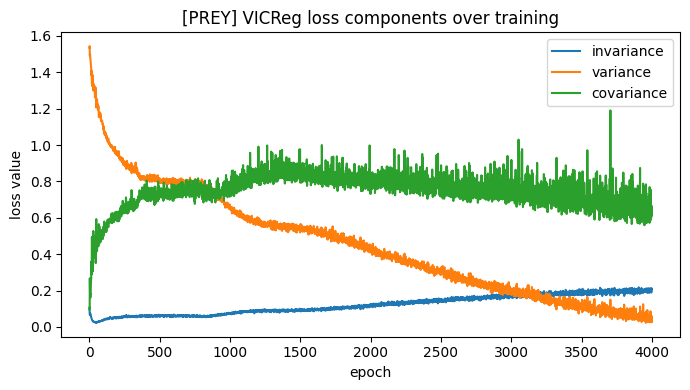

epoch 010: loss=23.902178 sim=0.0609 std=1.3949 cov=0.2912 std_mean=0.303
epoch 020: loss=22.802307 sim=0.0446 std=1.3157 cov=0.3902 std_mean=0.342
epoch 030: loss=21.968348 sim=0.0334 std=1.2890 cov=0.3597 std_mean=0.355
epoch 040: loss=21.405031 sim=0.0369 std=1.2019 cov=0.4907 std_mean=0.399
epoch 050: loss=20.769241 sim=0.0331 std=1.1785 cov=0.4527 std_mean=0.411
epoch 060: loss=20.465544 sim=0.0373 std=1.1446 cov=0.4731 std_mean=0.428
epoch 070: loss=20.285814 sim=0.0356 std=1.1221 cov=0.5126 std_mean=0.439
epoch 080: loss=20.065006 sim=0.0434 std=1.1022 cov=0.4893 std_mean=0.449
epoch 090: loss=19.757368 sim=0.0399 std=1.0767 cov=0.5216 std_mean=0.462
epoch 100: loss=19.361084 sim=0.0414 std=1.0407 cov=0.5431 std_mean=0.480
epoch 110: loss=19.469767 sim=0.0476 std=1.0350 cov=0.5512 std_mean=0.483
epoch 120: loss=19.195105 sim=0.0438 std=1.0266 cov=0.5403 std_mean=0.487
epoch 130: loss=19.080856 sim=0.0467 std=1.0039 cov=0.5709 std_mean=0.498
epoch 140: loss=19.084141 sim=0.0501 s

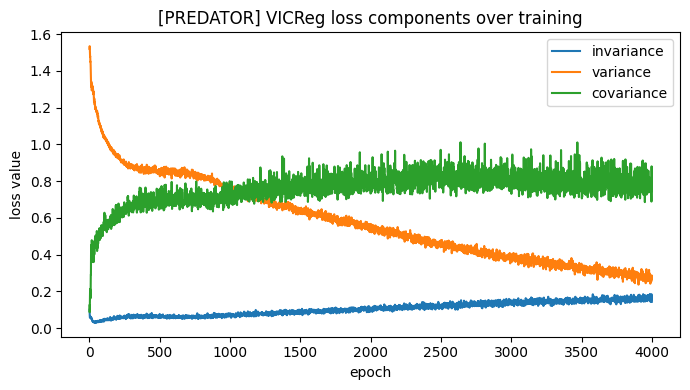

In [ ]:
# initialize trajectory augmentation
aug = TrajectoryAugmentation(noise_std=0.01, neigh_drop=0.10, feat_drop=0.05).to(device)

# pretrain prey encoder
prey_encoder = TransitionEncoder(features=6, embd_dim=32, z=32).to(device) # was 5
prey_projector = VicRegProjector(input_dim=64).to(device)
prey_optimizer = torch.optim.Adam(list(prey_encoder.parameters()) + list(prey_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(prey_encoder, prey_projector, aug=aug, exp_tensor=exp_prey_tensor, epochs=4000, optimizer=prey_optimizer, role="prey")
torch.save(prey_encoder.state_dict(),drive / f'models/trained_policies/Encoder/prey_encoder.pt')

# pretrain predator encoder
pred_encoder = TransitionEncoder(features=5, embd_dim=32, z=32).to(device) # was 4
pred_projector = VicRegProjector(input_dim=64).to(device)
pred_optimizer = torch.optim.Adam(list(pred_encoder.parameters()) + list(pred_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(pred_encoder, pred_projector, aug=aug, exp_tensor=exp_pred_tensor, epochs=4000, optimizer=pred_optimizer, role="predator")
torch.save(pred_encoder.state_dict(),drive / f'models/trained_policies/Encoder/pred_encoder.pt')

[PREDATOR] BC: keeping 33,939 / 33,939 samples (100.0%)
[PREDATOR] Epoch 25/2000 | train_loss:0.026177 | val_loss:0.025203
[PREDATOR] Epoch 50/2000 | train_loss:0.024196 | val_loss:0.023431
[PREDATOR] Epoch 75/2000 | train_loss:0.022525 | val_loss:0.021933
[PREDATOR] Epoch 100/2000 | train_loss:0.021296 | val_loss:0.020892
[PREDATOR] Epoch 125/2000 | train_loss:0.020260 | val_loss:0.020010
[PREDATOR] Epoch 150/2000 | train_loss:0.019556 | val_loss:0.019346
[PREDATOR] Epoch 175/2000 | train_loss:0.018827 | val_loss:0.018736
[PREDATOR] Epoch 200/2000 | train_loss:0.018249 | val_loss:0.018214
[PREDATOR] Epoch 225/2000 | train_loss:0.017800 | val_loss:0.017775
[PREDATOR] Epoch 250/2000 | train_loss:0.017320 | val_loss:0.018100
[PREDATOR] Epoch 275/2000 | train_loss:0.016907 | val_loss:0.017022
[PREDATOR] Epoch 300/2000 | train_loss:0.016466 | val_loss:0.016784
[PREDATOR] Epoch 325/2000 | train_loss:0.016425 | val_loss:0.016520
[PREDATOR] Early stopping at epoch 345.


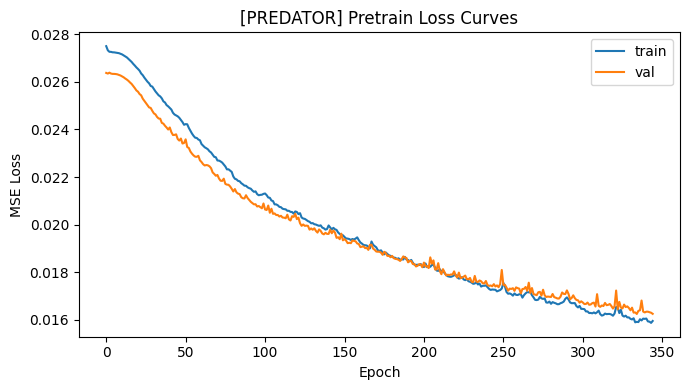

[PREY] BC: keeping 657,216 / 1,086,048 samples (60.5%)
[PREY] Epoch 25/2000 | train_loss:0.021624 | val_loss:0.021663
[PREY] Epoch 50/2000 | train_loss:0.021190 | val_loss:0.021210
[PREY] Epoch 75/2000 | train_loss:0.020821 | val_loss:0.020934
[PREY] Epoch 100/2000 | train_loss:0.020459 | val_loss:0.020580
[PREY] Epoch 125/2000 | train_loss:0.020154 | val_loss:0.020419
[PREY] Epoch 150/2000 | train_loss:0.019956 | val_loss:0.020144
[PREY] Epoch 175/2000 | train_loss:0.019739 | val_loss:0.019959
[PREY] Epoch 200/2000 | train_loss:0.019567 | val_loss:0.019998
[PREY] Early stopping at epoch 216.


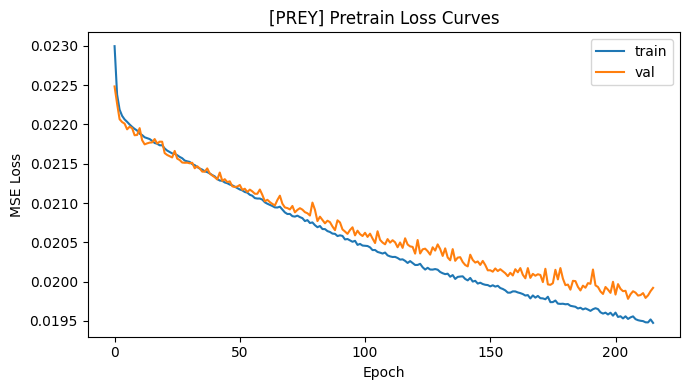

In [ ]:
# pretrain predator policy with behavior cloning and early stopping
pred_policy = ModularPolicy(features=5).to(device) # was 4
pretrain_policy(pred_policy, role="predator", expert_data=exp_pred_tensor,
                batch_size=4048, epochs=2000, lr=1e-3, patience=10,
                deterministic=True, device=device)
torch.save(pred_policy.state_dict(),drive / f'models/trained_policies/BC-Policy/bc_pred_policy.pt')


# pretrain prey policy with behavior cloning and early stopping
prey_policy = ModularPolicy(features=6).to(device) # was 5
pretrain_policy(prey_policy, role="prey", expert_data=exp_prey_tensor,
                batch_size=4048, epochs=2000, lr=1e-3, patience=10,
                deterministic=True, device=device)
torch.save(prey_policy.state_dict(),drive / f'models/trained_policies/BC-Policy/bc_prey_policy.pt')

### Pretrain Policy & Encoder (Attack Only)

In [ ]:
# import libraries + set working directory
import os, sys
import numpy as np
from pathlib import Path

drive = "/path/to/project"
drive = Path(drive)

os.chdir(drive)
sys.path.insert(0, drive)

print("Working directory:", os.getcwd())

Working directory: /path/to/project


In [ ]:
import torch
from pathlib import Path
from datetime import datetime

# project specific helper modules
from utils.sim_utils import *
from utils.train_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *

from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator

[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.


In [ ]:
window_len = 10
window_path = drive / f'Data/1. Data Processing/Processed/video/expert_tensors/windows/10 windows (split by attack or interaction -- used for calculating speed)/attack'

print(sorted(os.listdir(window_path)))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

['pred_tensors_hl_attack_w10_n2200.pkl', 'prey_tensors_hl_attack_w10_n2200.pkl']


In [ ]:
def load_expert_pairs(window_path, device=None):
    files = sorted(os.listdir(window_path))
    preds = [f for f in files if f.startswith('pred')]
    preys = [f for f in files if f.startswith('prey')]

    key = lambda name: name.split('_', 1)[1] # strip the pred/prey prefix
    pred_map = {key(f): f for f in preds}
    prey_map = {key(f): f for f in preys}

    unmatched = set(pred_map) ^ set(prey_map)
    if unmatched:
        raise RuntimeError(f"unpaired expert files: {sorted(unmatched)}")

    pred_list, prey_list = [], []
    for k in sorted(pred_map):
        pd = torch.load(os.path.join(window_path, pred_map[k]), weights_only=False)
        py = torch.load(os.path.join(window_path, prey_map[k]), weights_only=False)
        assert pd.shape[0] == py.shape[0], f"{k}: {pd.shape[0]} pred vs {py.shape[0]} prey"
        # print(f"  {pred_map[k]:<38s} {tuple(pd.shape)}")
        # print(f"  {prey_map[k]:<38s} {tuple(py.shape)}")
        pred_list.append(pd); prey_list.append(py)

    p = torch.cat(pred_list, 0).type(torch.float32)
    q = torch.cat(prey_list, 0).type(torch.float32)
    return (p.to(device), q.to(device)) if device else (p, q)

exp_pred_tensor, exp_prey_tensor = load_expert_pairs(window_path, device)
print("Pred Tensor Shape:", exp_pred_tensor.shape)
print("Prey Tensor Shape:", exp_prey_tensor.shape)

Pred Tensor Shape: torch.Size([2200, 10, 1, 32, 6])
Prey Tensor Shape: torch.Size([2200, 10, 32, 32, 7])


/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


epoch 010: loss=23.913511 sim=0.0474 std=1.3896 cov=0.3769 std_mean=0.305
epoch 020: loss=22.953789 sim=0.0343 std=1.3220 cov=0.4531 std_mean=0.339
epoch 030: loss=22.214649 sim=0.0273 std=1.2976 cov=0.4136 std_mean=0.351
epoch 040: loss=21.781071 sim=0.0269 std=1.2538 cov=0.4602 std_mean=0.373
epoch 050: loss=21.238091 sim=0.0279 std=1.2243 cov=0.4353 std_mean=0.388
epoch 060: loss=20.661125 sim=0.0318 std=1.1546 cov=0.5093 std_mean=0.423
epoch 070: loss=20.315481 sim=0.0341 std=1.1282 cov=0.5077 std_mean=0.436
epoch 080: loss=20.025986 sim=0.0359 std=1.1061 cov=0.5074 std_mean=0.447
epoch 090: loss=19.774586 sim=0.0392 std=1.0719 cov=0.5433 std_mean=0.464
epoch 100: loss=19.556145 sim=0.0414 std=1.0587 cov=0.5281 std_mean=0.471
epoch 110: loss=19.389214 sim=0.0429 std=1.0300 cov=0.5732 std_mean=0.485
epoch 120: loss=19.133099 sim=0.0426 std=1.0207 cov=0.5519 std_mean=0.490
epoch 130: loss=18.936611 sim=0.0458 std=0.9950 cov=0.5737 std_mean=0.503
epoch 140: loss=18.782322 sim=0.0422 s

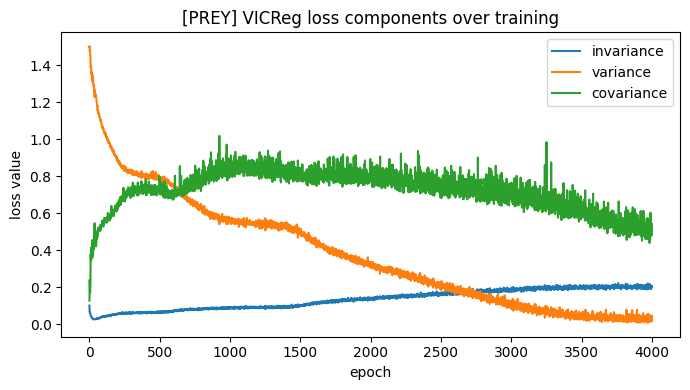

epoch 010: loss=23.808327 sim=0.0512 std=1.3634 cov=0.4157 std_mean=0.318
epoch 020: loss=22.843536 sim=0.0435 std=1.3343 cov=0.3481 std_mean=0.333
epoch 030: loss=21.906349 sim=0.0326 std=1.2722 cov=0.4019 std_mean=0.364
epoch 040: loss=21.426777 sim=0.0316 std=1.1941 cov=0.5452 std_mean=0.403
epoch 050: loss=20.878998 sim=0.0290 std=1.1878 cov=0.4673 std_mean=0.406
epoch 060: loss=20.431004 sim=0.0301 std=1.1414 cov=0.5116 std_mean=0.429
epoch 070: loss=20.149176 sim=0.0339 std=1.1246 cov=0.4863 std_mean=0.438
epoch 080: loss=19.960438 sim=0.0387 std=1.1016 cov=0.4942 std_mean=0.449
epoch 090: loss=19.891130 sim=0.0482 std=1.0676 cov=0.5343 std_mean=0.466
epoch 100: loss=19.494753 sim=0.0447 std=1.0496 cov=0.5265 std_mean=0.475
epoch 110: loss=19.275278 sim=0.0436 std=1.0256 cov=0.5604 std_mean=0.487
epoch 120: loss=19.042622 sim=0.0431 std=1.0077 cov=0.5698 std_mean=0.496
epoch 130: loss=19.155981 sim=0.0501 std=1.0054 cov=0.5644 std_mean=0.497
epoch 140: loss=18.988697 sim=0.0538 s

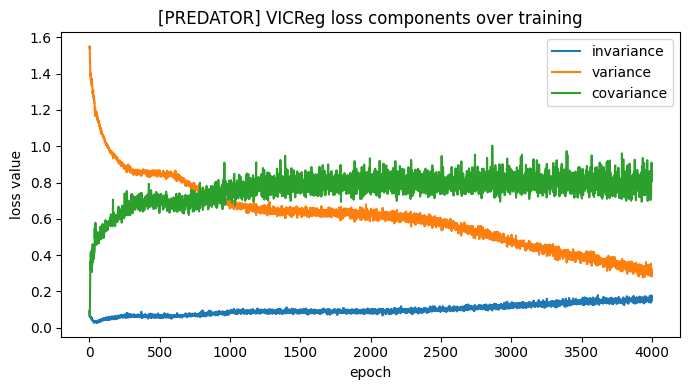

In [ ]:
# initialize trajectory augmentation
aug = TrajectoryAugmentation(noise_std=0.01, neigh_drop=0.10, feat_drop=0.05).to(device)

# pretrain prey encoder
prey_encoder = TransitionEncoder(features=6, embd_dim=32, z=32).to(device) # was 5
prey_projector = VicRegProjector(input_dim=64).to(device)
prey_optimizer = torch.optim.Adam(list(prey_encoder.parameters()) + list(prey_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(prey_encoder, prey_projector, aug=aug, exp_tensor=exp_prey_tensor, epochs=4000, optimizer=prey_optimizer, role="prey")
torch.save(prey_encoder.state_dict(),drive / f'models/trained_policies/Encoder/prey_encoder_attack.pt')

# pretrain predator encoder
pred_encoder = TransitionEncoder(features=5, embd_dim=32, z=32).to(device) # was 4
pred_projector = VicRegProjector(input_dim=64).to(device)
pred_optimizer = torch.optim.Adam(list(pred_encoder.parameters()) + list(pred_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(pred_encoder, pred_projector, aug=aug, exp_tensor=exp_pred_tensor, epochs=4000, optimizer=pred_optimizer, role="predator")
torch.save(pred_encoder.state_dict(),drive / f'models/trained_policies/Encoder/pred_encoder_attack.pt')

[PREDATOR] BC: keeping 19,800 / 19,800 samples (100.0%)
[PREDATOR] Epoch 25/2000 | train_loss:0.027415 | val_loss:0.027955
[PREDATOR] Epoch 50/2000 | train_loss:0.026277 | val_loss:0.026979
[PREDATOR] Epoch 75/2000 | train_loss:0.024974 | val_loss:0.025842
[PREDATOR] Epoch 100/2000 | train_loss:0.023643 | val_loss:0.024476
[PREDATOR] Epoch 125/2000 | train_loss:0.022523 | val_loss:0.023595
[PREDATOR] Epoch 150/2000 | train_loss:0.021332 | val_loss:0.022546
[PREDATOR] Epoch 175/2000 | train_loss:0.020658 | val_loss:0.022332
[PREDATOR] Epoch 200/2000 | train_loss:0.019831 | val_loss:0.021248
[PREDATOR] Epoch 225/2000 | train_loss:0.019164 | val_loss:0.020484
[PREDATOR] Epoch 250/2000 | train_loss:0.018657 | val_loss:0.020050
[PREDATOR] Epoch 275/2000 | train_loss:0.018126 | val_loss:0.019639
[PREDATOR] Epoch 300/2000 | train_loss:0.017570 | val_loss:0.019231
[PREDATOR] Epoch 325/2000 | train_loss:0.017044 | val_loss:0.018720
[PREDATOR] Early stopping at epoch 347.


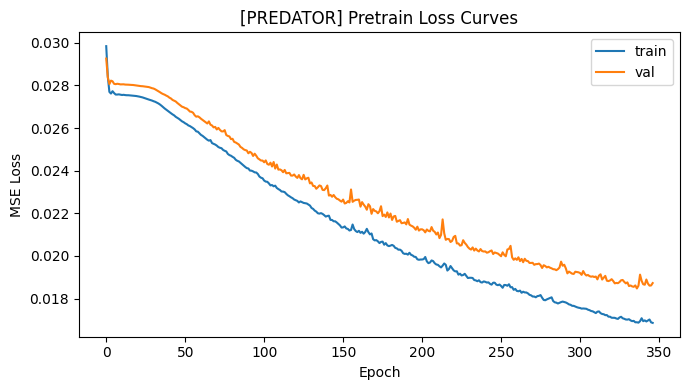

[PREY] BC: keeping 427,536 / 633,600 samples (67.5%)
[PREY] Epoch 25/2000 | train_loss:0.027569 | val_loss:0.027540
[PREY] Epoch 50/2000 | train_loss:0.026981 | val_loss:0.027067
[PREY] Epoch 75/2000 | train_loss:0.026549 | val_loss:0.026743
[PREY] Epoch 100/2000 | train_loss:0.026174 | val_loss:0.026676
[PREY] Epoch 125/2000 | train_loss:0.025852 | val_loss:0.026177
[PREY] Epoch 150/2000 | train_loss:0.025520 | val_loss:0.025928
[PREY] Epoch 175/2000 | train_loss:0.025193 | val_loss:0.025567
[PREY] Epoch 200/2000 | train_loss:0.024859 | val_loss:0.025341
[PREY] Epoch 225/2000 | train_loss:0.024614 | val_loss:0.025376
[PREY] Early stopping at epoch 226.


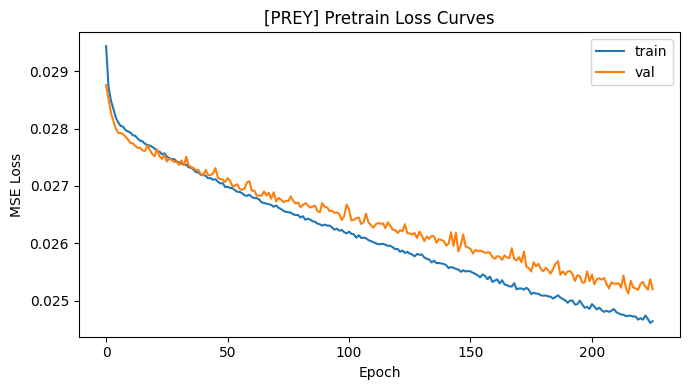

In [ ]:
# pretrain predator policy with behavior cloning and early stopping
pred_policy = ModularPolicy(features=5).to(device) # was 4
pretrain_policy(pred_policy, role="predator", expert_data=exp_pred_tensor,
                batch_size=4048, epochs=2000, lr=1e-3, patience=10,
                deterministic=True, device=device)
torch.save(pred_policy.state_dict(),drive / f'models/trained_policies/BC-Policy/bc_pred_policy_attack.pt')


# pretrain prey policy with behavior cloning and early stopping
prey_policy = ModularPolicy(features=6).to(device) # was 5
pretrain_policy(prey_policy, role="prey", expert_data=exp_prey_tensor,
                batch_size=4048, epochs=2000, lr=1e-3, patience=10,
                deterministic=True, device=device)
torch.save(prey_policy.state_dict(),drive / f'models/trained_policies/BC-Policy/bc_prey_policy_attack.pt')